# Parte 1

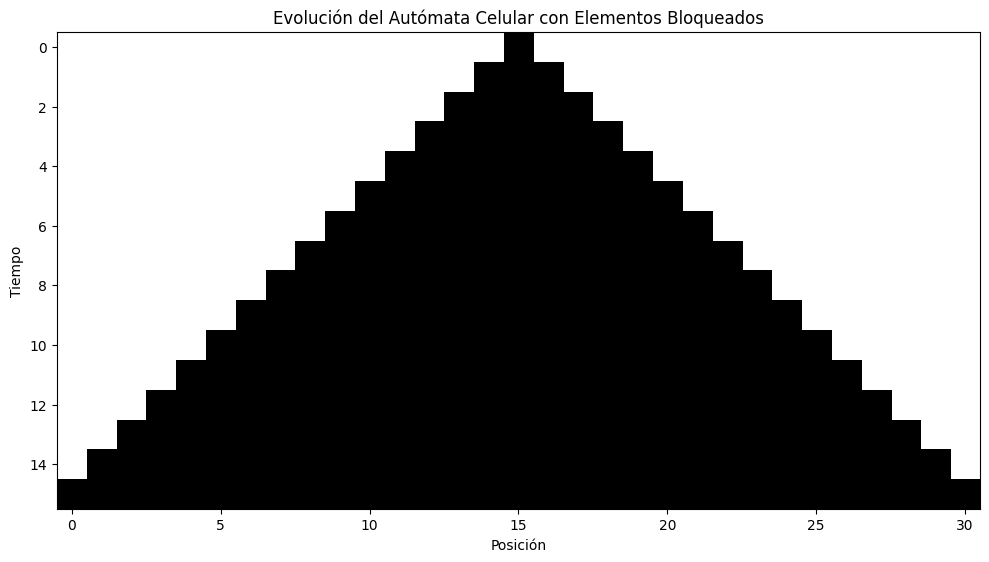

In [26]:
import numpy as np
import matplotlib.pyplot as plt

class AutomataCelular:
    def __init__(self, largo=41):
        self.largo = largo
        # Inicializar con ceros y un 1 en el centro
        self.celdas = np.zeros(largo, dtype=int)
        self.celdas[largo // 2] = 1
        
        # Capa de elementos bloqueados (inicialmente sin bloqueos)
        self.bloqueados = np.zeros(largo, dtype=bool)
        
    def establecer_bloqueados(self, posiciones):
        """Establece las posiciones que permanecerán con valor 1 y no cambiarán"""
        self.bloqueados = np.zeros(self.largo, dtype=bool)
        for pos in posiciones:
            if 0 <= pos < self.largo:
                self.bloqueados[pos] = True
                self.celdas[pos] = 1  # Aseguramos que las posiciones bloqueadas tengan valor 1
    
    def decimal_a_binario(self, n, bits=8):
        """Convierte un número decimal a binario de 8 bits"""
        return format(n, f'0{bits}b')
        
    def generar_tabla_reglas(self, rule_number):
        """Genera un diccionario con las reglas del autómata"""
        # Convertir el número de regla a binario (8 bits)
        rule_bin = self.decimal_a_binario(rule_number)
        # Todos los posibles estados de vecindad
        estados = ["111", "110", "101", "100", "011", "010", "001", "000"]
        # Crear el diccionario de reglas
        return {estados[i]: int(rule_bin[i]) for i in range(8)}
        
    def vecindad(self, celdas, i):
        """Devuelve el vecindario de una celda"""
        izq = celdas[(i-1) % self.largo]  # Condiciones periódicas
        centro = celdas[i]
        der = celdas[(i+1) % self.largo]  # Condiciones periódicas
        return f"{izq}{centro}{der}"
        
    def evolucionar(self, regla):
        """Genera la siguiente generación aplicando la regla, manteniendo los elementos bloqueados"""
        tabla_reglas = self.generar_tabla_reglas(regla)
        nueva_gen = np.zeros(self.largo, dtype=int)
        
        for i in range(self.largo):
            if self.bloqueados[i]:
                # Si la celda está bloqueada, mantiene su valor (1)
                nueva_gen[i] = 1
            else:
                # Si no está bloqueada, aplica la regla normalmente
                vecindad = self.vecindad(self.celdas, i)
                nueva_gen[i] = tabla_reglas[vecindad]
            
        self.celdas = nueva_gen
        return nueva_gen.copy()
        
    def ejecutar(self, secuencia_reglas):
        """Ejecuta el autómata con una secuencia de reglas"""
        # Inicializar la matriz que guardará toda la historia
        # Calculamos el número total de generaciones
        total_generaciones = sum(rep for _, rep in secuencia_reglas)
        # Crear matriz: filas = generaciones + 1 (estado inicial), columnas = largo
        matriz_historia = np.zeros((total_generaciones + 1, self.largo), dtype=int)
        # Guardar el estado inicial en la primera fila
        matriz_historia[0] = self.celdas.copy()
        
        fila_actual = 1  # Empezamos a guardar desde la fila 1
        
        # Iterar sobre cada regla y sus repeticiones
        for regla, repeticiones in secuencia_reglas:
            for _ in range(repeticiones):
                # Evolucionar el autómata
                self.evolucionar(regla)
                # Guardar el estado actual en la matriz de historia
                matriz_historia[fila_actual] = self.celdas.copy()
                fila_actual += 1
                
        # Visualizar la historia
        self.graficar(matriz_historia)
        return matriz_historia
        
    def graficar(self, matriz_historia):
        """Grafica la evolución del autómata celular"""
        plt.figure(figsize=(10, 10))
        plt.imshow(matriz_historia, cmap='binary', interpolation='none')
        plt.title(f'Evolución del Autómata Celular con Elementos Bloqueados')
        plt.xlabel('Posición')
        plt.ylabel('Tiempo')
        
        # Marcar las posiciones bloqueadas en el eje X
        pos_bloqueadas = np.where(self.bloqueados)[0]
        if len(pos_bloqueadas) > 0:
            plt.xticks(pos_bloqueadas)
            
        plt.tight_layout()
        plt.show()
        

# Ejemplo de uso
if __name__ == "__main__":
    # Crear el autómata
    automata = AutomataCelular(largo=31)
    
    # Definir posiciones bloqueadas (ejemplos)
    posiciones_bloqueadas = [1, 80]
    #automata.establecer_bloqueados(posiciones_bloqueadas) ######################################################################
    
    # Definir la secuencia de reglas: [(regla, repeticiones), ...]
    secuencia = [(222, 15)]  # Regla 90 por 40 pasos
    
    # Ejecutar el autómata
    historia = automata.ejecutar(secuencia)
    